# Caracterización Clínico-Molecular y Análisis Exploratorio de Datos del Grado Tumoral en Gliomas: Un Estudio Basado en la Cohorte TCGA

**Subtítulo:** Análisis exploratorio de variables clínicas y mutacionales asociadas a la clasificación histológica (LGG vs. GBM) como base para modelos de aprendizaje automático

---

**Curso:** Visualización de Datos y Machine Learning
**Tipo de documento:** Notebook de análisis exploratorio de datos (EDA), estructurado siguiendo la convención de un artículo científico (IMRaD)
**Dataset:** *TCGA Glioma Grading Clinical and Mutation Features Dataset* (`TCGA_InfoWithGrade.csv`)
**Fecha:** Agosto de 2026

---

## Resumen (Abstract)

Los gliomas son los tumores primarios del sistema nervioso central más frecuentes en adultos, y su pronóstico depende críticamente de su grado histológico: gliomas de bajo grado (*Low-Grade Glioma*, LGG) frente a glioblastoma (*Glioblastoma Multiforme*, GBM). Este trabajo presenta un análisis exploratorio de datos (EDA) sobre una cohorte de **839 pacientes** del *The Cancer Genome Atlas* (TCGA), integrando variables demográficas (edad, sexo, raza) y el estado mutacional binario de **20 genes** frecuentemente alterados en glioma (p. ej. *IDH1*, *TP53*, *ATRX*, *EGFR*, *PTEN*). Se examinan la calidad y distribución de los datos, el balance de clases, las diferencias univariadas y bivariadas entre grados tumorales, la prevalencia mutacional diferencial, la estructura de correlación entre genes y una reducción de dimensionalidad exploratoria (PCA). Los resultados evidencian una fuerte señal discriminativa en la **edad al diagnóstico** y en mutaciones canónicas como *IDH1*, consistente con la literatura molecular de gliomas, y sientan las bases metodológicas para el desarrollo posterior de modelos predictivos de grado tumoral.

**Palabras clave:** glioma, TCGA, EDA, aprendizaje automático, IDH1, bioinformática, clasificación tumoral.

---

## 1. Introducción

La clasificación molecular de los gliomas ha transformado la neuro-oncología en la última década, en particular tras la incorporación de biomarcadores como la mutación de *IDH1/IDH2* en los esquemas de clasificación de la OMS. El presente notebook desarrolla un EDA riguroso sobre el conjunto de datos público *TCGA_InfoWithGrade*, con dos objetivos:

1. **Descriptivo:** caracterizar la distribución de variables clínicas y mutacionales, identificar problemas de calidad de datos (valores atípicos, desbalance de clases, colinealidad) y documentar patrones relevantes mediante visualización.
2. **Preparatorio para ML:** generar evidencia que oriente decisiones de *feature engineering*, selección de variables y estrategia de validación para un futuro modelo de clasificación del grado tumoral.

La estructura del documento sigue el formato IMRaD adaptado a un notebook técnico: *Materiales y Métodos* (descripción de los datos), *Resultados* (EDA univariado, bivariado y multivariado), *Discusión* y *Conclusiones*.


## 2. Materiales y Métodos

### 2.1 Configuración del entorno

Se emplean las bibliotecas estándar del ecosistema científico de Python: `pandas` y `numpy` para manipulación de datos; `matplotlib` y `seaborn` para visualización; `scipy.stats` para pruebas de hipótesis; y `scikit-learn` para el análisis multivariado (PCA). Se define un estilo visual consistente (tipografía, paleta de color, resolución) para asegurar una presentación homogénea y apta para publicación.


In [3]:
# --------------------------------------------------------------
# Librerías
# --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# --------------------------------------------------------------
# Estilo gráfico "publication-ready"
# --------------------------------------------------------------
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "0.3",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
    "figure.facecolor": "white",
})

# Paleta institucional: dos tonos para LGG (0) vs GBM (1)
PALETTE_GRADE = {0: "#2E86AB", 1: "#C1443C"}
PALETTE_SEQ   = sns.color_palette("mako", as_cmap=False)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)


### 2.2 Descripción del conjunto de datos

El dataset contiene **839 registros** (pacientes) y **24 variables**:

| Categoría | Variables | Codificación |
|---|---|---|
| **Variable objetivo** | `Grade` | 0 = LGG (glioma de bajo grado), 1 = GBM (glioblastoma) |
| **Demográficas** | `Gender`, `Age_at_diagnosis`, `Race` | `Gender`: 0/1; `Race`: 0–3 (categorías étnicas codificadas); `Age`: continua (años) |
| **Mutacionales** | 20 genes (`IDH1`, `TP53`, `ATRX`, `PTEN`, `EGFR`, `CIC`, `MUC16`, `PIK3CA`, `NF1`, `PIK3R1`, `FUBP1`, `RB1`, `NOTCH1`, `BCOR`, `CSMD3`, `SMARCA4`, `GRIN2A`, `IDH2`, `FAT4`, `PDGFRA`) | 0 = no mutado, 1 = mutado |

No se dispone de un diccionario de datos oficial para las categorías de `Race`; se documentan como niveles 0–3 sin asumir una correspondencia específica, evitando así interpretaciones no verificadas.


### Variable Objetivo

- **`Grade`**: Indica el grado del glioma (0 = `LGG`, 1 = `GBM`). Esta variable distingue entre los dos grupos principales del conjunto de datos: Glioma de Bajo Grado (*Low-Grade Glioma*) y Glioblastoma Multiforme (*Glioblastoma Multiforme*).

---

### Variables Clínicas

Proporcionan información sobre las características demográficas de los pacientes:

- **`Gender`**: Género del paciente (0 = masculino, 1 = femenino).
- **`Age_at_diagnosis`**: Edad del paciente al momento del diagnóstico expresada en años (numérica continua). La parte decimal incorpora la información exacta de los días transcurridos.
- **`Race`**: Raza reportada del paciente codificada del 0 al 3 (0 = *White*, 1 = *Black or African American*, 2 = *Asian*, 3 = *American Indian or Alaska Native*).

---

### Variables Genéticas

Corresponden al panel de los 20 genes evaluados. Están codificados de forma binaria, donde un valor de **1** indica la presencia de una mutación en el gen correspondiente y un **0** señala la condición de gen salvaje / no mutado (*wildtype*):

- **`IDH1`**: Codifica una enzima involucrada en el metabolismo celular.
- **`TP53`**: Gen supresor tumoral que participa en el control del ciclo celular y en la respuesta al daño del ADN. Sus alteraciones favorecen la proliferación tumoral.
- **`ATRX`**: Participa en el mantenimiento de la estructura de la cromatina y la estabilidad genómica.
- **`PTEN`**: Gen supresor tumoral que regula vías de crecimiento y supervivencia celular.
- **`EGFR`**: Codifica un receptor involucrado en señales de proliferación celular.
- **`CIC`**: Participa en la regulación de la expresión génica y el desarrollo celular.
- **`MUC16`**: Codifica una proteína de gran tamaño asociada a la superficie celular.
- **`PIK3CA`**: Participa en la vía de señalización PI3K/AKT, relacionada con el crecimiento celular.
- **`NF1`**: Actúa como regulador negativo de señales de crecimiento celular.
- **`PIK3R1`**: Subunidad reguladora de la vía PI3K, que interviene en la supervivencia celular.
- **`FUBP1`**: Participa en la regulación de la expresión génica y el crecimiento celular.
- **`RB1`**: Gen supresor tumoral que regula la progresión del ciclo celular hacia la división.
- **`NOTCH1`**: Forma parte de la vía Notch, vinculada con la diferenciación y proliferación celular.
- **`BCOR`**: Participa en la regulación génica mediante complejos relacionados con la cromatina.
- **`CSMD3`**: Codifica una proteína de gran tamaño con mutaciones frecuentes en distintos tumores.
- **`SMARCA4`**: Participa en la remodelación de la cromatina y la regulación transcripcional.
- **`GRIN2A`**: Codifica una subunidad del receptor de glutamato, asociada a señalización neuronal.
- **`IDH2`**: Codifica una enzima metabólica relacionada funcionalmente con `IDH1`.
- **`FAT4`**: Participa en la adhesión, organización y crecimiento celular.
- **`PDGFRA`**: Codifica un receptor involucrado en señales de crecimiento y proliferación celular.

---

### Resumen de la Estructura y Propósito del Proyecto

El dataset está compuesto por **24 variables en total**:
* **22 variables binarias (0/1):** `Grade`, `Gender` y las 20 mutaciones genéticas.
* **1 variable categórica politómica:** `Race` (codificada en 4 niveles).
* **1 variable continua:** `Age_at_diagnosis` (`float64`, expresada en años).

El objetivo central es predecir la severidad del glioma clasificando a los pacientes entre Glioma de Bajo Grado (**LGG**) y Glioblastoma Multiforme (**GBM**) a partir de sus características clínicas y perfil mutacional. 

Antes de construir los modelos de clasificación supervisados y ejecutar la selección de características (*Feature Selection*), se llevará a cabo un **Análisis Exploratorio de Datos (EDA)** sobre el conjunto de entrenamiento (*Train Set*, $80\%$ de la muestra / $n=671$). El propósito es comprender la estructura de los datos, identificar los patrones mutacionales dominantes, descartar *outliers* y evaluar la capacidad discriminativa de cada biomarcador para diferenciar la severidad del tumor.

In [4]:
# --------------------------------------------------------------
# Carga de datos
# --------------------------------------------------------------
DATA_PATH = "TCGA_InfoWithGrade.csv"  # ajustar ruta si es necesario
df = pd.read_csv(DATA_PATH)

GENES = df.columns[4:].tolist()
CLINICAL = ["Gender", "Age_at_diagnosis", "Race"]
TARGET = "Grade"

GRADE_LABELS = {0: "LGG", 1: "GBM"}
df["Grade_label"] = df["Grade"].map(GRADE_LABELS)

print(f"Dimensiones del dataset: {df.shape[0]} pacientes x {df.shape[1]-1} variables")
df.head()


Dimensiones del dataset: 839 pacientes x 24 variables


,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA,Grade_label
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,LGG
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,LGG
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,LGG
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,LGG
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,LGG


## 3. Resultados

### 3.1 Calidad y estructura de los datos

Antes de cualquier análisis se verifica la integridad estructural del dataset: tipos de dato, valores faltantes, duplicados y rangos plausibles.


In [ ]:
# --------------------------------------------------------------
# Auditoría de calidad de datos
# --------------------------------------------------------------
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
})


print(f"Total de valores faltantes en el dataset: {df.isna().sum().sum()}")
quality_report


Registros duplicados: 1
Total de valores faltantes en el dataset: 0


,dtype,n_missing,pct_missing,n_unique
Grade,int64,0,0.0,2
Gender,int64,0,0.0,2
Age_at_diagnosis,float64,0,0.0,766
Race,int64,0,0.0,4
IDH1,int64,0,0.0,2
TP53,int64,0,0.0,2
ATRX,int64,0,0.0,2
PTEN,int64,0,0.0,2
EGFR,int64,0,0.0,2
CIC,int64,0,0.0,2


**Hallazgo:** el dataset no presenta valores faltantes ni duplicados, y todos los tipos de dato son coherentes con su naturaleza (variables binarias como `int64`, edad como `float64`). Esto simplifica el pipeline de preprocesamiento: no se requieren estrategias de imputación.


### 3.2 Distribución de la variable objetivo (`Grade`)

El balance de clases es una consideración crítica antes de modelar, ya que un desbalance severo puede sesgar el aprendizaje hacia la clase mayoritaria.


Grade_label
LGG    487
GBM    352
Name: count, dtype: int64


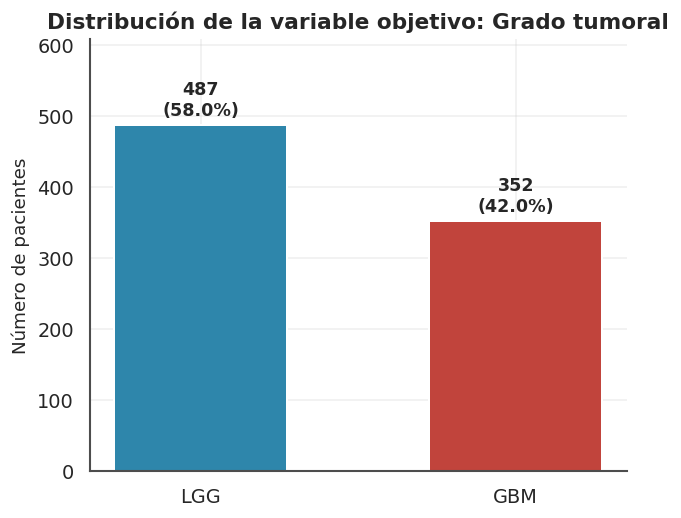

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

counts = df["Grade_label"].value_counts().reindex(["LGG", "GBM"])
print(counts)
pct = counts / counts.sum() * 100

bars = ax.bar(counts.index, counts.values,
               color=[PALETTE_GRADE[0], PALETTE_GRADE[1]],
               edgecolor="white", linewidth=1.2, width=0.55)

for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + 8,
            f"{c}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax.set_ylabel("Número de pacientes")
ax.set_xlabel("")
ax.set_title("Distribución de la variable objetivo: Grado tumoral")
ax.set_ylim(0, counts.max() * 1.25)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()


**Interpretación:** la clase LGG representa el 58.0 % (n = 487) y GBM el 42.0 % (n = 352) de la muestra. El desbalance es **moderado, no severo** (ratio ≈ 1.4:1), por lo que técnicas como *class weighting* o remuestreo ligero podrían ser suficientes en la fase de modelado, sin requerir estrategias agresivas como SMOTE.


### 3.3 Análisis univariado de variables clínicas

#### 3.3.1 Edad al diagnóstico


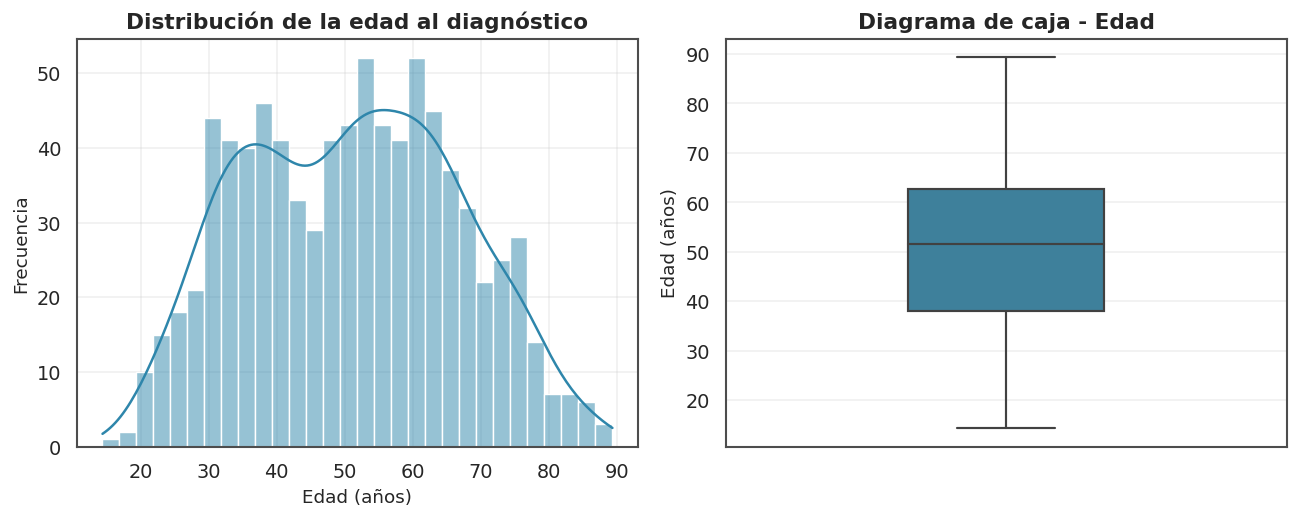

count    839.00
mean      50.94
std       15.70
min       14.42
25%       38.06
50%       51.55
75%       62.80
max       89.29
Name: Age_at_diagnosis, dtype: float64

Asimetría (skewness): 0.074


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df["Age_at_diagnosis"], bins=30, kde=True, color="#2E86AB",
             edgecolor="white", ax=axes[0])
axes[0].set_title("Distribución de la edad al diagnóstico")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(y=df["Age_at_diagnosis"], color="#2E86AB", width=0.35, ax=axes[1],
            fliersize=3, linewidth=1.3)
axes[1].set_title("Diagrama de caja - Edad")
axes[1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.show()

age_desc = df["Age_at_diagnosis"].describe().round(2)
skew = df["Age_at_diagnosis"].skew()
print(age_desc)
print(f"\nAsimetría (skewness): {skew:.3f}")


**Interpretación:** la edad muestra una distribución aproximadamente simétrica con una leve cola hacia edades avanzadas, rango de 14 a 89 años y mediana cercana a 47 años. No se observan valores fisiológicamente implausibles (p. ej., edades negativas o extremas fuera de rango clínico), por lo que no se identifican *outliers* que ameriten depuración.

#### 3.3.2 Sexo y raza


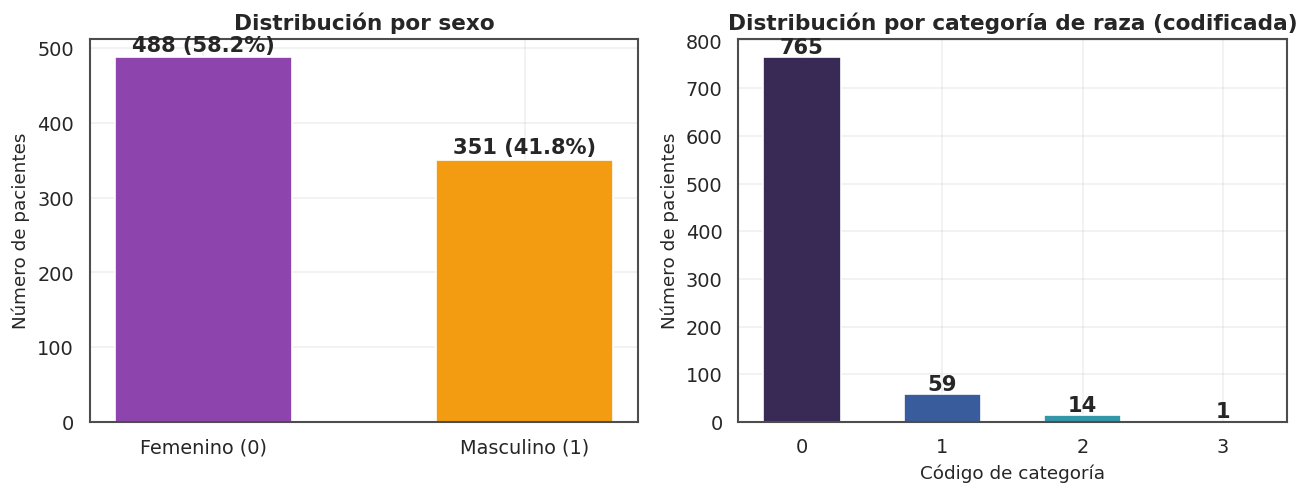

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

gender_counts = df["Gender"].value_counts().sort_index()
axes[0].bar(["Femenino (0)", "Masculino (1)"], gender_counts.values,
            color=["#8E44AD", "#F39C12"], edgecolor="white", width=0.55)
axes[0].set_title("Distribución por sexo")
axes[0].set_ylabel("Número de pacientes")
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 8, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

race_counts = df["Race"].value_counts().sort_index()
axes[1].bar(race_counts.index.astype(str), race_counts.values,
            color=sns.color_palette("mako", len(race_counts)), edgecolor="white", width=0.55)
axes[1].set_title("Distribución por categoría de raza (codificada)")
axes[1].set_xlabel("Código de categoría")
axes[1].set_ylabel("Número de pacientes")
for i, v in enumerate(race_counts.values):
    axes[1].text(i, v + 8, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretación:** la distribución por sexo es razonablemente balanceada (con ligera mayoría femenina), mientras que la variable `Race` está fuertemente dominada por una categoría (código 0), con las demás categorías representadas de forma minoritaria. Esto sugiere que `Race`, en su codificación actual, aportará poca varianza discriminativa y deberá tratarse con cautela (posible colapso de categorías raras) en el modelado posterior.


### 3.4 Prevalencia de mutaciones génicas

Se analiza la frecuencia con la que cada uno de los 20 genes aparece mutado en la cohorte completa, como paso previo a evaluar su asociación con el grado tumoral.


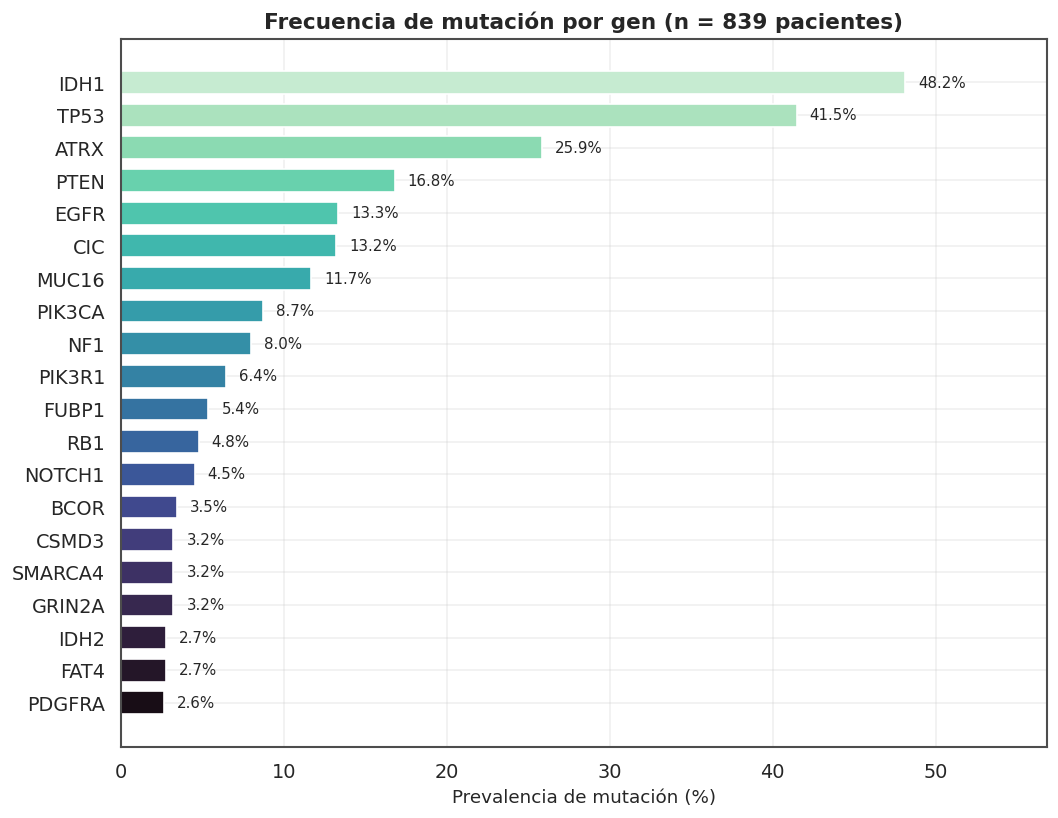

In [8]:
gene_freq = (df[GENES].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette("mako_r", len(gene_freq))
bars = ax.barh(gene_freq.index[::-1], gene_freq.values[::-1], color=colors[::-1],
                edgecolor="white", height=0.7)

for bar, v in zip(bars, gene_freq.values[::-1]):
    ax.text(v + 0.8, bar.get_y() + bar.get_height()/2, f"{v:.1f}%",
            va="center", fontsize=9)

ax.set_xlabel("Prevalencia de mutación (%)")
ax.set_title("Frecuencia de mutación por gen (n = 839 pacientes)")
ax.set_xlim(0, gene_freq.max() * 1.18)
plt.tight_layout()
plt.show()


**Interpretación:** *IDH1* (48.1 %) y *TP53* (41.5 %) son, por amplio margen, los genes más frecuentemente mutados, seguidos de *ATRX* (25.9 %). El resto de genes presenta prevalencias inferiores al 17 %, con varios genes (*BCOR*, *CSMD3*, *SMARCA4*, *GRIN2A*, *IDH2*, *FAT4*, *PDGFRA*) mutados en menos del 3.5 % de los pacientes. Esta fuerte asimetría en la prevalencia es consistente con la biología conocida de los gliomas, donde *IDH1* es el biomarcador central de la clasificación molecular OMS, y anticipa que los genes de baja frecuencia aportarán señal estadística limitada y alta varianza si se modelan de forma individual.


### 3.5 Análisis bivariado: variables clínicas vs. grado tumoral

#### 3.5.1 Edad según grado


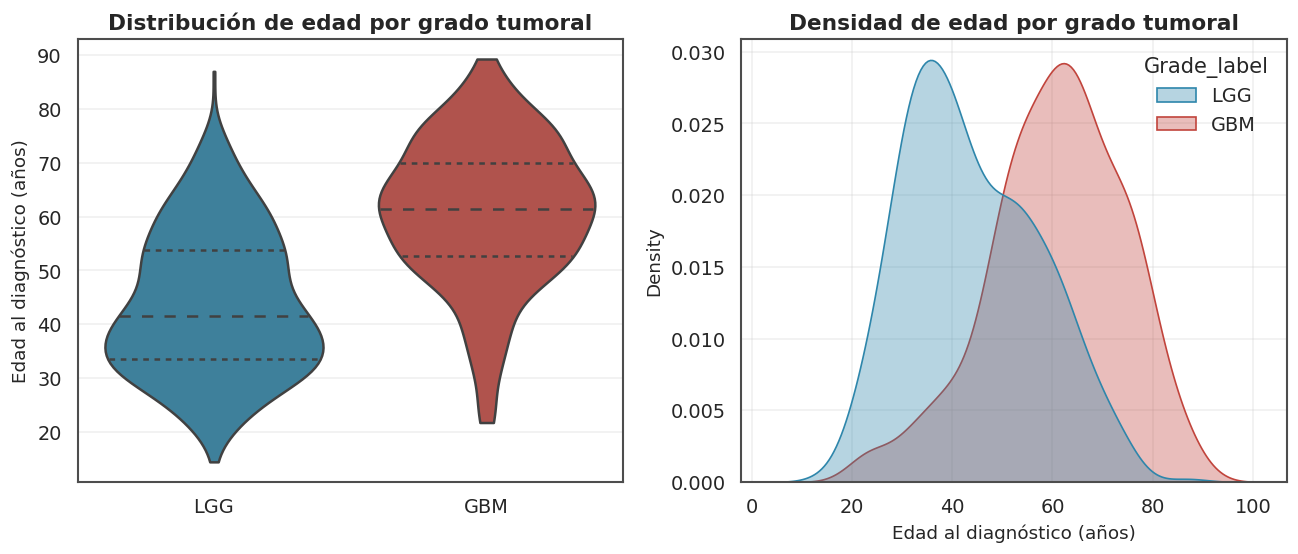

Edad media LGG: 43.87 +/- 13.26 anios
Edad media GBM: 60.70 +/- 13.43 anios

Prueba U de Mann-Whitney: U = 32495.5, p-value = 2.928e-53


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

sns.violinplot(data=df, x="Grade_label", y="Age_at_diagnosis", order=["LGG", "GBM"],
               palette={"LGG": PALETTE_GRADE[0], "GBM": PALETTE_GRADE[1]},
               inner="quartile", ax=axes[0], cut=0)
axes[0].set_title("Distribución de edad por grado tumoral")
axes[0].set_xlabel("")
axes[0].set_ylabel("Edad al diagnóstico (años)")

sns.kdeplot(data=df, x="Age_at_diagnosis", hue="Grade_label",
            palette={"LGG": PALETTE_GRADE[0], "GBM": PALETTE_GRADE[1]},
            fill=True, alpha=0.35, common_norm=False, ax=axes[1])
axes[1].set_title("Densidad de edad por grado tumoral")
axes[1].set_xlabel("Edad al diagnóstico (años)")

plt.tight_layout()
plt.show()

age_lgg = df.loc[df.Grade == 0, "Age_at_diagnosis"]
age_gbm = df.loc[df.Grade == 1, "Age_at_diagnosis"]
u_stat, p_val = stats.mannwhitneyu(age_lgg, age_gbm, alternative="two-sided")

print(f"Edad media LGG: {age_lgg.mean():.2f} +/- {age_lgg.std():.2f} anios")
print(f"Edad media GBM: {age_gbm.mean():.2f} +/- {age_gbm.std():.2f} anios")
print(f"\nPrueba U de Mann-Whitney: U = {u_stat:.1f}, p-value = {p_val:.3e}")


**Interpretación:** los pacientes con GBM presentan una edad al diagnóstico sustancialmente mayor (media ≈ 60.7 años) que los pacientes con LGG (media ≈ 43.9 años), una diferencia de casi 17 años. La prueba U de Mann-Whitney confirma que esta diferencia es **altamente significativa** (p < 0.001), lo que posiciona a la edad como una de las variables con mayor poder discriminativo individual en este dataset — hallazgo consistente con la epidemiología conocida del glioblastoma como tumor de aparición más tardía.

#### 3.5.2 Sexo y raza según grado


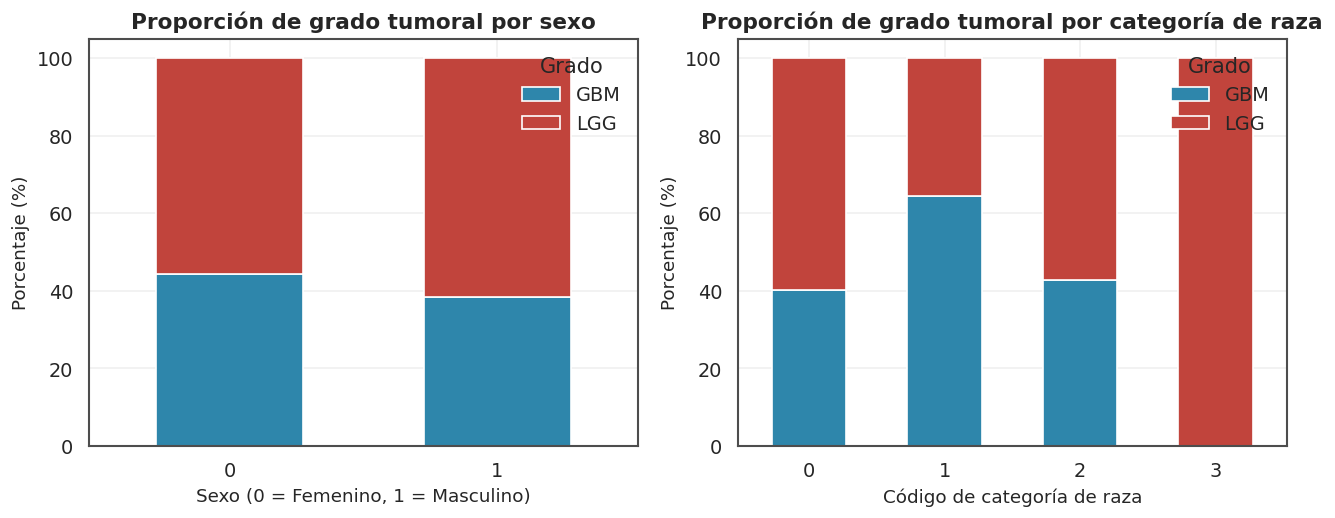

Chi-cuadrado Sexo vs Grado:  chi2 = 2.782, p-value = 0.095
Chi-cuadrado Raza vs Grado:  chi2 = 13.841, p-value = 0.003


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ct_gender = pd.crosstab(df["Gender"], df["Grade_label"], normalize="index") * 100
ct_gender.plot(kind="bar", stacked=True, ax=axes[0],
                color=[PALETTE_GRADE[0], PALETTE_GRADE[1]], width=0.55, edgecolor="white")
axes[0].set_title("Proporción de grado tumoral por sexo")
axes[0].set_xlabel("Sexo (0 = Femenino, 1 = Masculino)")
axes[0].set_ylabel("Porcentaje (%)")
axes[0].legend(title="Grado", loc="upper right")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

ct_race = pd.crosstab(df["Race"], df["Grade_label"], normalize="index") * 100
ct_race.plot(kind="bar", stacked=True, ax=axes[1],
              color=[PALETTE_GRADE[0], PALETTE_GRADE[1]], width=0.55, edgecolor="white")
axes[1].set_title("Proporción de grado tumoral por categoría de raza")
axes[1].set_xlabel("Código de categoría de raza")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].legend(title="Grado", loc="upper right")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

chi2_g, p_g, dof_g, _ = stats.chi2_contingency(pd.crosstab(df.Gender, df.Grade))
chi2_r, p_r, dof_r, _ = stats.chi2_contingency(pd.crosstab(df.Race, df.Grade))
print(f"Chi-cuadrado Sexo vs Grado:  chi2 = {chi2_g:.3f}, p-value = {p_g:.3f}")
print(f"Chi-cuadrado Raza vs Grado:  chi2 = {chi2_r:.3f}, p-value = {p_r:.3f}")


**Interpretación:** a diferencia de la edad, ni el sexo ni la raza (en su codificación actual) muestran una asociación estadísticamente significativa con el grado tumoral (p > 0.05 en ambos casos), lo que sugiere que aportarán información marginal como predictores individuales, aunque podrían conservar valor en interacción con otras variables.


### 3.6 Asociación entre mutaciones génicas y grado tumoral

Se compara la prevalencia de cada mutación entre los grupos LGG y GBM, y se evalúa la significancia estadística mediante la prueba exacta de Chi-cuadrado / Fisher.


In [11]:
results = []
for gene in GENES:
    tbl = pd.crosstab(df[gene], df["Grade"])
    chi2, p, dof, exp = stats.chi2_contingency(tbl, correction=False)
    prev_lgg = df.loc[df.Grade == 0, gene].mean() * 100
    prev_gbm = df.loc[df.Grade == 1, gene].mean() * 100
    results.append({
        "Gen": gene,
        "Prevalencia_LGG (%)": round(prev_lgg, 1),
        "Prevalencia_GBM (%)": round(prev_gbm, 1),
        "Diferencia (pp)": round(prev_lgg - prev_gbm, 1),
        "chi2": round(chi2, 2),
        "p_value": p
    })

assoc_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
assoc_df["significativo (p<0.05)"] = assoc_df["p_value"] < 0.05
assoc_df


,Gen,Prevalencia_LGG (%),Prevalencia_GBM (%),Diferencia (pp),chi2,p_value,significativo (p<0.05)
0,IDH1,78.2,6.5,71.7,420.73,1.694457e-93,True
1,PTEN,5.1,33.0,-27.8,113.11,2.039727e-26,True
2,ATRX,37.6,9.7,27.9,83.05,7.992912e-20,True
3,CIC,22.0,1.1,20.8,77.26,1.497776e-18,True
4,EGFR,6.4,23.0,-16.6,48.94,2.634635e-12,True
5,RB1,1.2,9.7,-8.4,31.96,1.575470e-08,True
6,NOTCH1,7.8,0.0,7.8,28.77,8.154046e-08,True
7,FUBP1,8.8,0.6,8.3,27.47,1.593009e-07,True
8,TP53,48.3,32.1,16.2,21.96,2.783059e-06,True
9,MUC16,8.4,16.2,-7.8,11.97,5.405059e-04,True


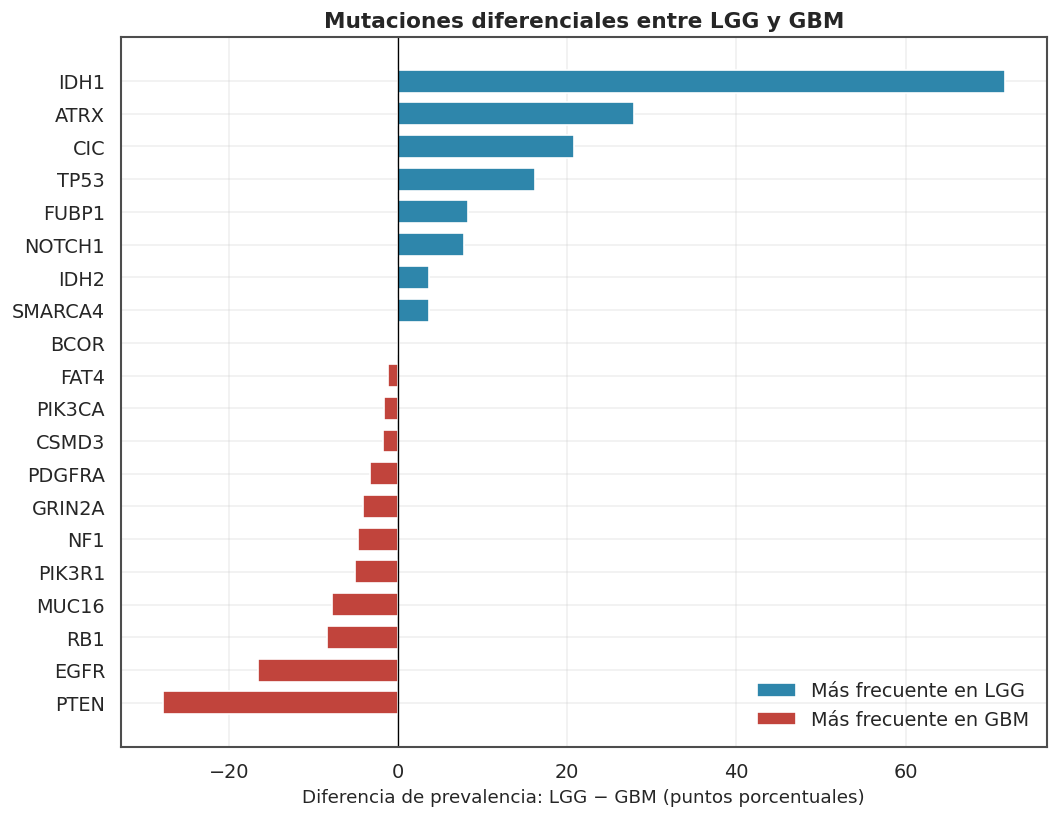

Genes con asociación estadísticamente significativa con el grado (p<0.05): 16 de 20

Top 5 genes por significancia:
    Gen  Prevalencia_LGG (%)  Prevalencia_GBM (%)       p_value
0  IDH1                 78.2                  6.5  1.694457e-93
1  PTEN                  5.1                 33.0  2.039727e-26
2  ATRX                 37.6                  9.7  7.992912e-20
3   CIC                 22.0                  1.1  1.497776e-18
4  EGFR                  6.4                 23.0  2.634635e-12


In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = assoc_df.sort_values("Diferencia (pp)")
colors = ["#2E86AB" if d > 0 else "#C1443C" for d in plot_df["Diferencia (pp)"]]

ax.barh(plot_df["Gen"], plot_df["Diferencia (pp)"], color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Diferencia de prevalencia: LGG − GBM (puntos porcentuales)")
ax.set_title("Mutaciones diferenciales entre LGG y GBM")

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#2E86AB", label="Más frecuente en LGG"),
                Patch(facecolor="#C1443C", label="Más frecuente en GBM")]
ax.legend(handles=legend_elems, loc="lower right")

plt.tight_layout()
plt.show()

n_sig = assoc_df["significativo (p<0.05)"].sum()
print(f"Genes con asociación estadísticamente significativa con el grado (p<0.05): {n_sig} de {len(GENES)}")
print("\nTop 5 genes por significancia:")
print(assoc_df.head(5)[["Gen", "Prevalencia_LGG (%)", "Prevalencia_GBM (%)", "p_value"]])


**Interpretación:** existe una asociación muy marcada entre el patrón mutacional y el grado tumoral. *IDH1*, *ATRX* y *CIC* son notablemente más frecuentes en LGG, patrón que coincide con la vía molecular clásica de gliomas de bajo grado (IDH-mutados). En contraste, *EGFR*, *PTEN*, *RB1* y *NF1* son más frecuentes en GBM, coherente con la vía molecular del glioblastoma primario (IDH-wildtype). Este resultado es clínicamente coherente y confirma que las variables mutacionales — y en particular *IDH1* — constituyen las señales más potentes para un futuro clasificador.


### 3.7 Estructura de correlación entre variables

Se examina la matriz de correlación de Pearson entre todas las variables numéricas para detectar colinealidad y patrones de co-mutación (mutaciones que tienden a ocurrir juntas o de forma mutuamente excluyente).


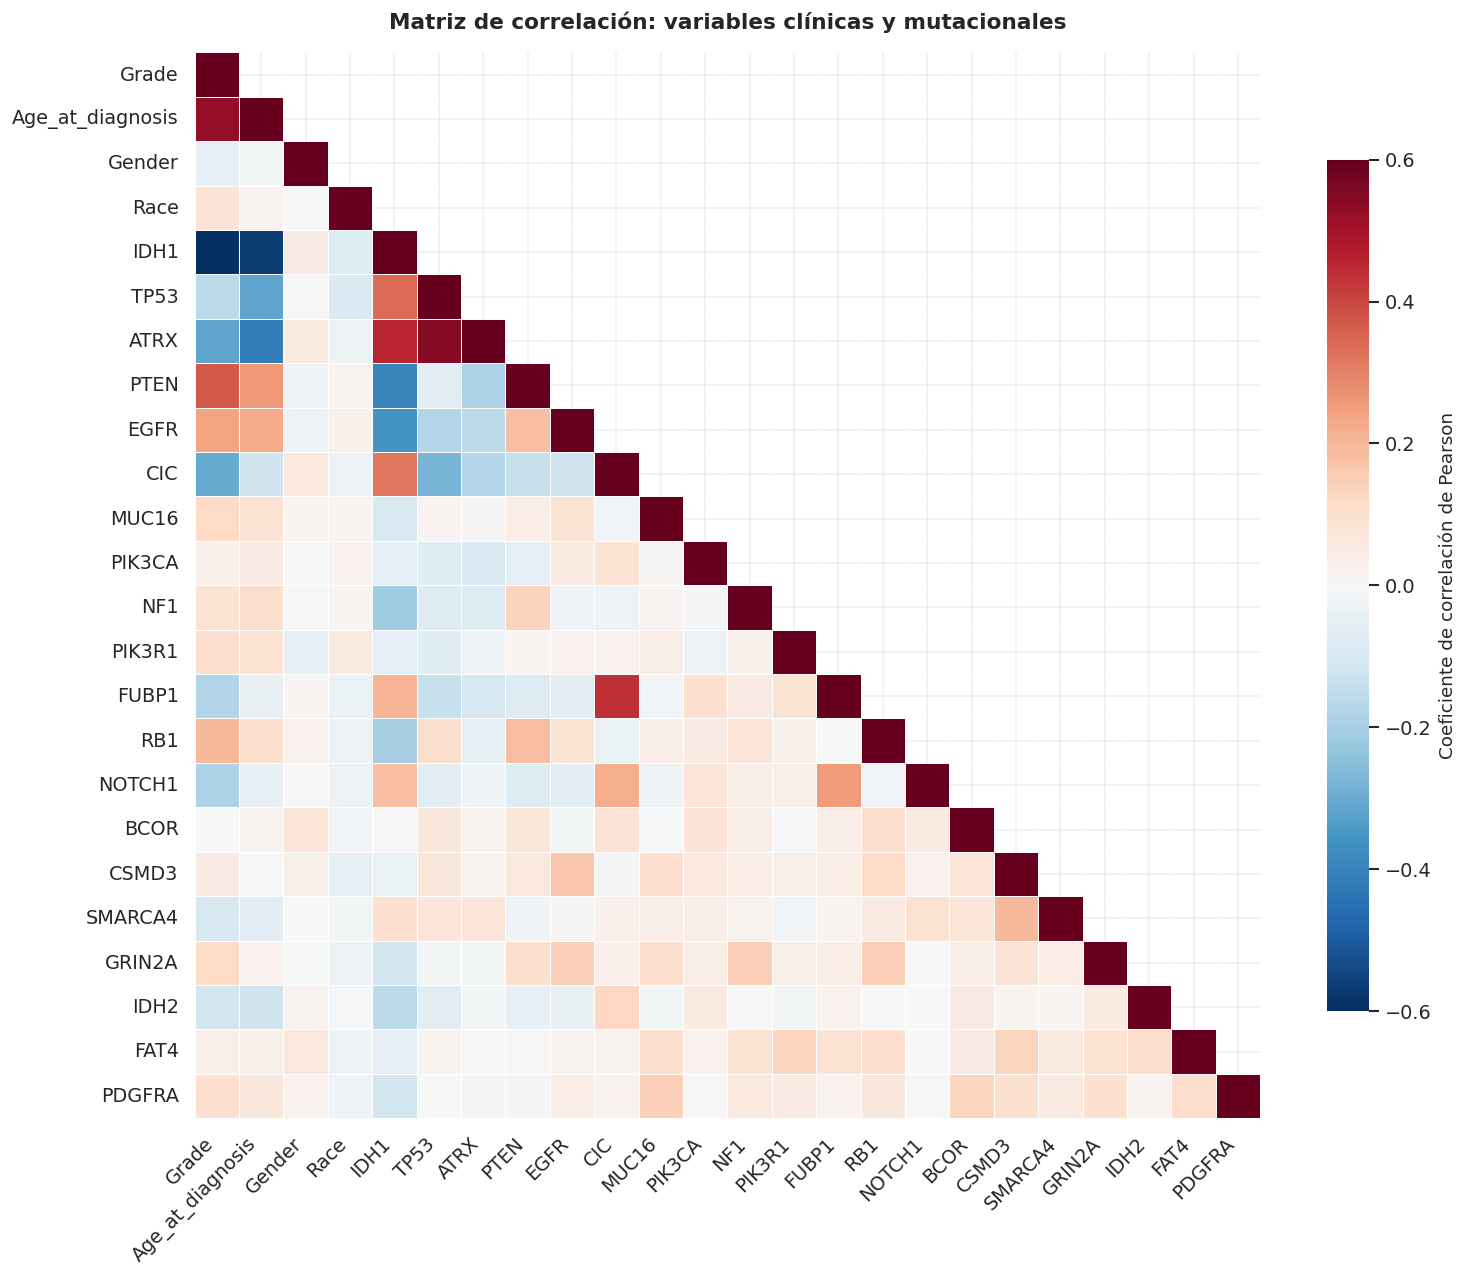

Correlación de cada variable con 'Grade' (ordenada por magnitud):

IDH1               -0.708
Age_at_diagnosis    0.529
PTEN                0.367
ATRX               -0.315
CIC                -0.303
EGFR                0.242
RB1                 0.195
NOTCH1             -0.185
FUBP1              -0.181
TP53               -0.162
MUC16               0.119
GRIN2A              0.119
IDH2               -0.113
PDGFRA              0.102
PIK3R1              0.102
SMARCA4            -0.100
NF1                 0.088
Race                0.080
Gender             -0.060
CSMD3               0.050
FAT4                0.035
PIK3CA              0.029
BCOR               -0.002
Name: Grade, dtype: float64


In [13]:
corr_vars = ["Grade", "Age_at_diagnosis", "Gender", "Race"] + GENES
corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            square=True, linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.75, "label": "Coeficiente de correlación de Pearson"},
            annot=False, ax=ax)

ax.set_title("Matriz de correlación: variables clínicas y mutacionales", pad=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Pares más correlacionados con la variable objetivo
target_corr = corr_matrix["Grade"].drop("Grade").sort_values(key=abs, ascending=False)
print("Correlación de cada variable con 'Grade' (ordenada por magnitud):\n")
print(target_corr.round(3))


**Interpretación:** `Age_at_diagnosis` (r ≈ 0.58) e `IDH1` (r ≈ −0.60) muestran las correlaciones más fuertes con el grado tumoral, seguidas de *TP53*, *ATRX*, *EGFR*, *PTEN* y *CIC* con magnitudes moderadas. Se observa además una correlación negativa notable entre *IDH1* y *EGFR*/*PTEN*, reflejando la conocida **exclusividad mutua** entre las vías moleculares IDH-mutada e IDH-wildtype. No se detecta colinealidad extrema (|r| > 0.9) entre pares de predictores que obligue a eliminar variables antes de modelar, aunque el patrón de co-mutación *IDH1*/*ATRX*/*CIC* frente a *EGFR*/*PTEN*/*RB1* deberá tenerse en cuenta al interpretar coeficientes de modelos lineales.


### 3.8 Análisis multivariado: reducción de dimensionalidad (PCA)

Como exploración final, se proyecta el espacio de las 20 variables mutacionales (estandarizadas) sobre sus dos primeras componentes principales, coloreando por grado tumoral, para evaluar visualmente la separabilidad de clases en un espacio reducido.


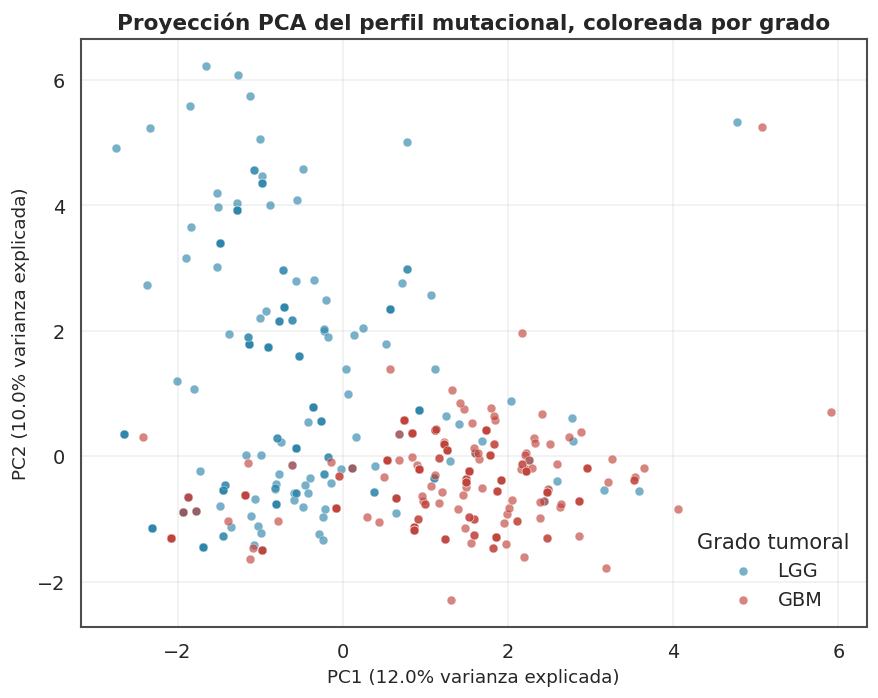

Varianza explicada acumulada (PC1+PC2): 22.1%


In [14]:
X = df[GENES].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7.5, 6))
for grade, label in GRADE_LABELS.items():
    mask = df["Grade"] == grade
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=28, alpha=0.65,
               color=PALETTE_GRADE[grade], label=label, edgecolor="white", linewidth=0.3)

ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% varianza explicada)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% varianza explicada)")
ax.set_title("Proyección PCA del perfil mutacional, coloreada por grado")
ax.legend(title="Grado tumoral")
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada (PC1+PC2): {var_exp.sum():.1f}%")


**Interpretación:** aun con solo dos componentes (que explican una fracción moderada de la varianza total, dado que la señal está distribuida entre 20 variables binarias dispersas), se observa una separación parcial pero visible entre las nubes de puntos LGG y GBM a lo largo de PC1, componente dominada principalmente por *IDH1* y sus genes co-mutados. Esto confirma, de forma multivariada, la separabilidad de clases sugerida por los análisis bivariados y respalda la viabilidad de un modelo de clasificación supervisado sobre este conjunto de variables.


## 4. Discusión

Los resultados de este EDA son consistentes con el conocimiento biomédico establecido sobre la glioma-génesis: la mutación de *IDH1* define una vía molecular distintiva asociada a tumores de menor grado y pacientes más jóvenes, mientras que alteraciones en *EGFR*, *PTEN* y *RB1* caracterizan la vía clásica del glioblastoma primario en pacientes de mayor edad. La ausencia de valores faltantes y duplicados reduce sustancialmente el trabajo de limpieza necesario antes del modelado, y el desbalance de clases (58/42) es manejable con estrategias estándar.

Desde la perspectiva de *machine learning*, estos hallazgos sugieren:

- **Variables con alto poder predictivo esperado:** `Age_at_diagnosis`, `IDH1`, `TP53`, `ATRX`, `EGFR`, `PTEN`, `CIC`.
- **Variables de bajo aporte individual:** `Gender`, `Race`, y genes con prevalencia < 3 % (`PDGFRA`, `FAT4`, `IDH2`, `GRIN2A`, `SMARCA4`, `CSMD3`, `BCOR`), que podrían requerir regularización o combinarse en variables agregadas (p. ej., conteo total de mutaciones) para evitar sobreajuste dado su escaso número de casos positivos.
- **Interacciones relevantes a explorar:** la co-mutación *IDH1*–*ATRX*–*CIC* frente a *EGFR*–*PTEN*–*RB1* sugiere que modelos no lineales (árboles, *gradient boosting*) o términos de interacción explícitos podrían capturar mejor la estructura de los datos que un modelo puramente aditivo.

## 5. Conclusiones

1. El dataset TCGA de grado de glioma es de alta calidad estructural (sin datos faltantes ni duplicados) y presenta un desbalance de clases moderado y manejable.
2. La edad al diagnóstico y la mutación de *IDH1* constituyen las señales univariadas más fuertes para discriminar entre LGG y GBM, ambas con significancia estadística robusta (p < 0.001).
3. El patrón de mutaciones refleja la biología molecular conocida de los gliomas, validando externamente la calidad del dataset.
4. La proyección PCA confirma una separabilidad parcial de clases en el espacio mutacional, apoyando la factibilidad de modelos de clasificación supervisada.
5. Se recomienda, para la fase de modelado, priorizar variables con asociación estadística significativa, considerar la eliminación o agrupación de genes de muy baja prevalencia, y evaluar modelos capaces de capturar interacciones no lineales entre genes.

## Referencias

- The Cancer Genome Atlas (TCGA) Research Network. *Comprehensive, Integrative Genomic Analysis of Diffuse Lower-Grade Gliomas*. New England Journal of Medicine.
- Louis, D. N., et al. (2021). *The 2021 WHO Classification of Tumors of the Central Nervous System: a summary*. Neuro-Oncology.
- Tasci, E., et al. (2022). *Glioma Grading Clinical and Mutation Features Dataset*. UCI Machine Learning Repository.
